In [9]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt

# NSL-KDD column names
columns = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes",
    "land","wrong_fragment","urgent","hot","num_failed_logins","logged_in",
    "num_compromised","root_shell","su_attempted","num_root",
    "num_file_creations","num_shells","num_access_files","num_outbound_cmds",
    "is_host_login","is_guest_login","count","srv_count","serror_rate",
    "srv_serror_rate","rerror_rate","srv_rerror_rate","same_srv_rate",
    "diff_srv_rate","srv_diff_host_rate","dst_host_count",
    "dst_host_srv_count","dst_host_same_srv_rate","dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate","dst_host_srv_diff_host_rate",
    "dst_host_serror_rate","dst_host_srv_serror_rate",
    "dst_host_rerror_rate","dst_host_srv_rerror_rate",
    "label","difficulty"
]

In [10]:
df = pd.read_csv("../data/KDDTrain+.txt", names=columns, sep="\t")


print(df.shape)
df.head()

(125973, 43)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [11]:
# Binary target: normal = 0, attack = 1
y = df['label'].apply(lambda x: 0 if x == 'normal' else 1)

# Drop label + difficulty
X = df.drop(['label', 'difficulty'], axis=1)

# One-hot encode categorical features
X = pd.get_dummies(X)

print("Features after encoding:", X.shape)

Features after encoding: (125973, 122)


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [13]:
import time

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)


start = time.time()
rf.fit(X_train, y_train)
train_time = time.time() - start

print(f"\nTraining time: {train_time:.2f}s")



Training time: 5.85s


In [14]:
y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9989680492161143

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     13469
           1       1.00      1.00      1.00     11726

    accuracy                           1.00     25195
   macro avg       1.00      1.00      1.00     25195
weighted avg       1.00      1.00      1.00     25195



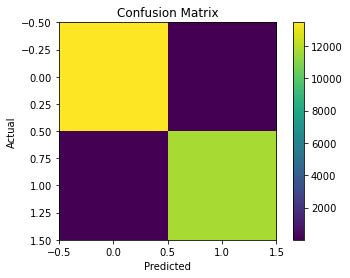

In [15]:
cm = confusion_matrix(y_test, y_pred)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [16]:
feature_importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values(by='importance', ascending=False)

print("\nTop 15 Features:")
print(feature_importance_df.head(15))

feature_importance_df.to_csv("feature_importance.csv", index=False)


Top 15 Features:
                         feature  importance
1                      src_bytes    0.150879
120                      flag_SF    0.082093
2                      dst_bytes    0.081333
8                      logged_in    0.064416
30        dst_host_same_srv_rate    0.062897
29            dst_host_srv_count    0.055734
25                 same_srv_rate    0.052708
35      dst_host_srv_serror_rate    0.040237
26                 diff_srv_rate    0.040128
38            protocol_type_icmp    0.031164
19                         count    0.027675
31        dst_host_diff_srv_rate    0.027472
65                  service_http    0.019661
28                dst_host_count    0.019647
33   dst_host_srv_diff_host_rate    0.019202


In [18]:
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('rf', RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42))
])

CV Accuracy: 0.9989442185831832 +/- 8.17255488000859e-05


In [ ]:
scores = cross_val_score(pipeline, X, y, cv=5, scoring='accuracy')
print("CV Accuracy:", scores.mean(), "+/-", scores.std())